# 数据挖掘期末大项目

## 项目主题：前程无忧招聘数据分析与挖掘

### 项目概述
本项目基于前程无忧招聘数据集，通过数据清洗、数据分析、数据可视化和机器学习等步骤，对Python开发工程师岗位的招聘信息进行深入挖掘，帮助用户理解招聘市场特征和薪资规律。

### 项目目标
1. 数据获取与读取
2. 数据清洗与预处理
3. 探索性数据分析
4. 数据可视化展示
5. 机器学习模型构建
6. 知识表示与总结

In [1]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import json
import re

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

---
## 一、数据获取与读取

### 1.1 读取CSV数据

In [2]:
# 读取CSV数据
df = pd.read_csv('前程无忧数据集.csv')

# 查看数据基本信息
print('数据形状:', df.shape)
print('\n数据列名:', df.columns.tolist())
print('\n数据类型:\n', df.dtypes)
print('\n前5行数据:')
df.head()

数据形状: (296, 10)

数据列名: ['岗位', '公司', '学历', '公司性质', '薪资', '学历要求', '工作经验', '公司规模', '公司类型', '公司福利']

数据类型:
 岗位      object
公司      object
学历      object
公司性质    object
薪资      object
学历要求    object
工作经验    object
公司规模    object
公司类型    object
公司福利    object
dtype: object

前5行数据:


,岗位,公司,学历,公司性质,薪资,学历要求,工作经验,公司规模,公司类型,公司福利
0,职位,公司,地点,公司性质,薪资,学历要求,工作经验,公司规模,公司类型,公司福利
1,Python开发工程师-CDN,华为技术有限公司,本科,民营公司,1.8-3.5万/月,1年经验,NaN,10000人以上,通信/电信运营、增值服务 通信/电信/网络设备,五险一金-通讯补贴-专业培训-绩效奖金-定期体检
2,Python开发工程师,北京点点智联科技有限公司,大专,创业公司,0.6-1.2万/月,1年经验,NaN,50-150人,计算机软件 通信/电信/网络设备,双休-定期体检-生日节日福利-项目绩效奖金-每年多次调薪-带薪培训-带薪年假
3,Python开发工程师,广东甜秘密寝具有限公司,本科,民营公司,5-6千/月,1年经验,NaN,500-1000人,互联网/电子商务 家具/家电/玩具/礼品,带薪年假-全勤奖-节日福利-专业培训-员工旅游-出国机会-年终奖金-员工体检
4,Python开发工程师,南京市斑马鱼数字智能科技有限责任公司,本科,民营公司,1-1.5万/月,1年经验,NaN,少于50人,计算机软件,弹性工作-定期体检-年终奖金-意外保险-五险一金


### 1.2 数据存储为JSON格式

In [3]:
# 将数据转换为JSON格式并保存
json_data = df.to_json(orient='records', force_ascii=False)

# 保存JSON文件
with open('前程无忧数据集.json', 'w', encoding='utf-8') as f:
    f.write(json_data)

# 读取JSON数据验证
with open('前程无忧数据集.json', 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

print('JSON数据加载成功，共', len(loaded_data), '条记录')
print('第一条记录:', loaded_data[0])

JSON数据加载成功，共 296 条记录
第一条记录: {'岗位': '职位', '公司': '公司', '学历': '地点', '公司性质': '公司性质', '薪资': '薪资', '学历要求': '学历要求', '工作经验': '工作经验', '公司规模': '公司规模', '公司类型': '公司类型', '公司福利': '公司福利'}


---
## 二、数据清洗与预处理

### 2.1 检查缺失值

In [4]:
# 检查缺失值
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'缺失数量': missing_values, '缺失百分比(%)': missing_percentage.round(2)})
missing_df = missing_df[missing_df['缺失数量'] > 0]
print('缺失值统计:')
missing_df

缺失值统计:


,缺失数量,缺失百分比(%)
薪资,1,0.34
学历要求,3,1.01
工作经验,280,94.59
公司类型,19,6.42
公司福利,47,15.88


### 2.2 数据清洗处理

In [5]:
# 复制数据进行清洗
clean_df = df.copy()

# 1. 删除第一行（错误的表头）
clean_df = clean_df.drop([0]).reset_index(drop=True)

# 2. 重置列名
clean_df.columns = ['岗位', '公司', '学历', '公司性质', '薪资', '学历要求', '工作经验', '公司规模', '公司类型', '公司福利']

# 3. 处理学历列的异常值（部分行学历和学历要求错位）
# 检查学历列是否包含经验相关内容
exp_pattern = r'(\d+年经验|无需经验|1年经验|2年经验|3-4年经验|5-7年经验|8-9年经验)'
clean_df['学历'] = clean_df.apply(lambda row: row['学历要求'] if re.match(exp_pattern, str(row['学历'])) else row['学历'], axis=1)

# 4. 填充缺失值
# 数值型特征用中位数填充
# 分类型特征用众数填充
for col in clean_df.columns:
    if clean_df[col].dtype == 'object':
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])
    else:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# 5. 验证清洗结果
print('清洗后缺失值统计:')
print(clean_df.isnull().sum())
print('\n清洗后前5行数据:')
clean_df.head()

清洗后缺失值统计:
岗位      0
公司      0
学历      0
公司性质    0
薪资      0
学历要求    0
工作经验    0
公司规模    0
公司类型    0
公司福利    0
dtype: int64

清洗后前5行数据:


,岗位,公司,学历,公司性质,薪资,学历要求,工作经验,公司规模,公司类型,公司福利
0,Python开发工程师-CDN,华为技术有限公司,本科,民营公司,1.8-3.5万/月,1年经验,英语良好,10000人以上,通信/电信运营、增值服务 通信/电信/网络设备,五险一金-通讯补贴-专业培训-绩效奖金-定期体检
1,Python开发工程师,北京点点智联科技有限公司,大专,创业公司,0.6-1.2万/月,1年经验,英语良好,50-150人,计算机软件 通信/电信/网络设备,双休-定期体检-生日节日福利-项目绩效奖金-每年多次调薪-带薪培训-带薪年假
2,Python开发工程师,广东甜秘密寝具有限公司,本科,民营公司,5-6千/月,1年经验,英语良好,500-1000人,互联网/电子商务 家具/家电/玩具/礼品,带薪年假-全勤奖-节日福利-专业培训-员工旅游-出国机会-年终奖金-员工体检
3,Python开发工程师,南京市斑马鱼数字智能科技有限责任公司,本科,民营公司,1-1.5万/月,1年经验,英语良好,少于50人,计算机软件,弹性工作-定期体检-年终奖金-意外保险-五险一金
4,Python开发工程师,壹沓科技（上海）有限公司,本科,民营公司,2.5-5万/月,3-4年经验,英语良好,计算机软件,计算机软件,五险一金-周末双休


### 2.3 薪资数据处理
薪资字段包含多种格式：
- X-Y万/月
- X-Y万/年
- X-Y千/月
需要统一转换为月薪（元）

In [6]:
# 薪资处理函数
def parse_salary(salary_str):
    salary_str = str(salary_str).strip()
    
    # 匹配 万/月 格式
    match_month_wan = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)万/月', salary_str)
    if match_month_wan:
        min_sal = float(match_month_wan.group(1)) * 10000
        max_sal = float(match_month_wan.group(2)) * 10000
        return (min_sal + max_sal) / 2
    
    # 匹配 万/年 格式
    match_year_wan = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)万/年', salary_str)
    if match_year_wan:
        min_sal = float(match_year_wan.group(1)) * 10000 / 12
        max_sal = float(match_year_wan.group(2)) * 10000 / 12
        return (min_sal + max_sal) / 2
    
    # 匹配 千/月 格式
    match_month_qian = re.match(r'(\d+\.?\d*)-(\d+\.?\d*)千/月', salary_str)
    if match_month_qian:
        min_sal = float(match_month_qian.group(1)) * 1000
        max_sal = float(match_month_qian.group(2)) * 1000
        return (min_sal + max_sal) / 2
    
    return None

# 应用薪资处理
clean_df['薪资_月薪(元)'] = clean_df['薪资'].apply(parse_salary)

# 删除薪资解析失败的行
clean_df = clean_df.dropna(subset=['薪资_月薪(元)'])

# 查看薪资处理结果
print('薪资处理后统计:')
print(clean_df['薪资_月薪(元)'].describe().round(2))
print('\n薪资处理后数据形状:', clean_df.shape)

薪资处理后统计:
count      295.00
mean     14850.56
std       5489.40
min       3750.00
25%      11500.00
50%      14500.00
75%      17500.00
max      37500.00
Name: 薪资_月薪(元), dtype: float64

薪资处理后数据形状: (295, 11)


### 2.4 工作经验数据处理

In [7]:
# 工作经验映射
experience_map = {
    '无需经验': 0,
    '1年经验': 1,
    '2年经验': 2,
    '3-4年经验': 3.5,
    '5-7年经验': 6,
    '8-9年经验': 8.5,
    '10年以上经验': 10
}

# 提取工作经验数值
def parse_experience(exp_str):
    exp_str = str(exp_str).strip()
    for key, value in experience_map.items():
        if key in exp_str:
            return value
    return np.nan

clean_df['工作经验_年'] = clean_df['工作经验'].apply(parse_experience)

# 填充工作经验缺失值为中位数
clean_df['工作经验_年'] = clean_df['工作经验_年'].fillna(clean_df['工作经验_年'].median())

print('工作经验处理结果:')
print(clean_df['工作经验_年'].value_counts().sort_index())

工作经验处理结果:
Series([], Name: count, dtype: int64)


### 2.5 公司规模处理

In [8]:
# 公司规模映射
size_map = {
    '少于50人': 25,
    '50-150人': 100,
    '150-500人': 325,
    '500-1000人': 750,
    '1000-5000人': 3000,
    '5000-10000人': 7500,
    '10000人以上': 15000
}

clean_df['公司规模_人数'] = clean_df['公司规模'].map(size_map)
clean_df['公司规模_人数'] = clean_df['公司规模_人数'].fillna(clean_df['公司规模_人数'].median())

print('公司规模处理结果:')
print(clean_df['公司规模_人数'].value_counts().sort_index())

公司规模处理结果:
公司规模_人数
25.0       36
100.0      74
325.0      87
750.0      39
3000.0     38
7500.0      8
15000.0    13
Name: count, dtype: int64


---
## 三、探索性数据分析

### 3.1 薪资分布分析

In [9]:
# 薪资描述统计
salary_stats = clean_df['薪资_月薪(元)'].describe()
print('薪资描述统计:')
print(salary_stats.round(2))

# 薪资分布
print('\n薪资区间分布:')
bins = [0, 5000, 10000, 15000, 20000, 30000, 50000]
labels = ['5k以下', '5k-10k', '10k-15k', '15k-20k', '20k-30k', '30k以上']
clean_df['薪资区间'] = pd.cut(clean_df['薪资_月薪(元)'], bins=bins, labels=labels)
print(clean_df['薪资区间'].value_counts().sort_index())

薪资描述统计:
count      295.00
mean     14850.56
std       5489.40
min       3750.00
25%      11500.00
50%      14500.00
75%      17500.00
max      37500.00
Name: 薪资_月薪(元), dtype: float64

薪资区间分布:
薪资区间
5k以下         2
5k-10k      58
10k-15k    117
15k-20k     77
20k-30k     38
30k以上        3
Name: count, dtype: int64


### 3.2 学历与薪资关系

In [10]:
# 学历分布
print('学历分布:')
print(clean_df['学历'].value_counts())

# 不同学历薪资对比
edu_salary = clean_df.groupby('学历')['薪资_月薪(元)'].agg(['mean', 'median', 'count']).round(2)
print('\n不同学历薪资统计:')
edu_salary.sort_values('mean', ascending=False)

学历分布:
学历
本科       205
大专        89
中技/中专      1
Name: count, dtype: int64

不同学历薪资统计:


,mean,median,count
学历,,,
本科,15530.08,15000.0,205
大专,13393.26,12500.0,89
中技/中专,5250.00,5250.0,1


### 3.3 公司性质与薪资关系

In [11]:
# 公司性质分布
print('公司性质分布:')
print(clean_df['公司性质'].value_counts())

# 不同公司性质薪资对比
nature_salary = clean_df.groupby('公司性质')['薪资_月薪(元)'].agg(['mean', 'median', 'count']).round(2)
print('\n不同公司性质薪资统计:')
nature_salary.sort_values('mean', ascending=False)

公司性质分布:
公司性质
民营公司       205
上市公司        26
合资          19
外资（欧美）      13
外资（非欧美）     12
国企          11
创业公司         7
事业单位         2
Name: count, dtype: int64

不同公司性质薪资统计:


,mean,median,count
公司性质,,,
外资（欧美）,19339.74,22500.0,13
上市公司,16878.21,16750.0,26
合资,15973.68,15000.0,19
外资（非欧美）,15458.33,12000.0,12
民营公司,14366.67,14000.0,205
国企,13409.09,11000.0,11
创业公司,12928.57,11500.0,7
事业单位,9250.00,9250.0,2


### 3.4 工作经验与薪资关系

In [33]:
# 工作经验分布
print('工作经验分布:')
print(clean_df['工作经验'].value_counts())

# 不同工作经验薪资对比
exp_salary = clean_df.groupby('工作经验')['薪资_月薪(元)'].agg(['mean', 'median', 'count']).round(2)
print('\n不同工作经验薪资统计:')
exp_salary.sort_values('mean', ascending=False)

工作经验分布:
工作经验
英语良好          284
英语熟练            3
普通话             2
英语一般            1
普通话良好           1
普通话精通&英语良好      1
英语良好&普通话良好      1
英语精通            1
普通话熟练           1
Name: count, dtype: int64

不同工作经验薪资统计:


,mean,median,count
工作经验,,,
英语熟练,22000.00,22500.00,3
英语精通,16500.00,16500.00,1
普通话熟练,15000.00,15000.00,1
普通话良好,15000.00,15000.00,1
英语良好,14814.55,14250.00,284
普通话,14250.00,14250.00,2
英语一般,12500.00,12500.00,1
普通话精通&英语良好,10500.00,10500.00,1
英语良好&普通话良好,9583.33,9583.33,1


---
## 四、数据可视化

### 4.1 薪资分布图

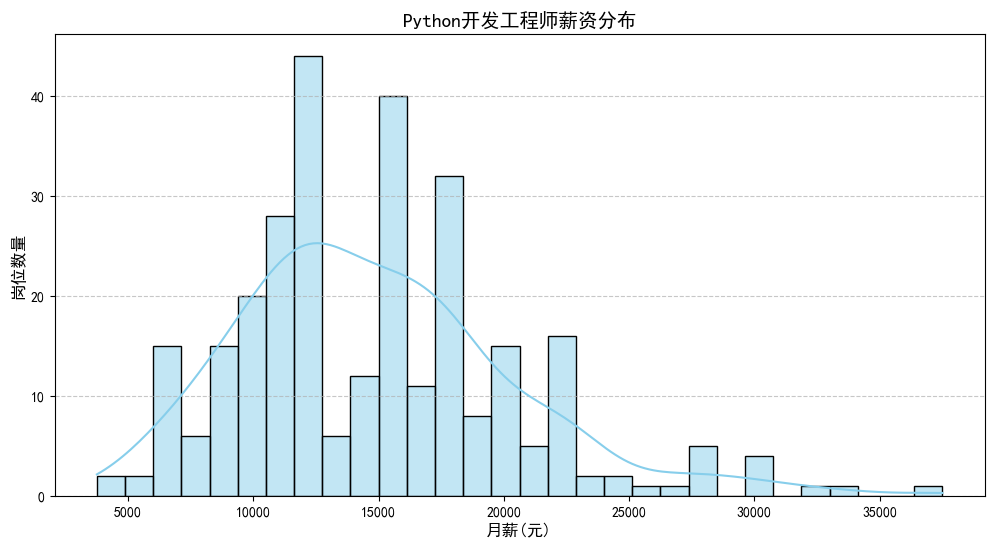

In [12]:
# 薪资直方图
plt.figure(figsize=(12, 6))
sns.histplot(clean_df['薪资_月薪(元)'], bins=30, kde=True, color='skyblue')
plt.title('Python开发工程师薪资分布', fontsize=14)
plt.xlabel('月薪(元)', fontsize=12)
plt.ylabel('岗位数量', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.2 薪资区间分布图

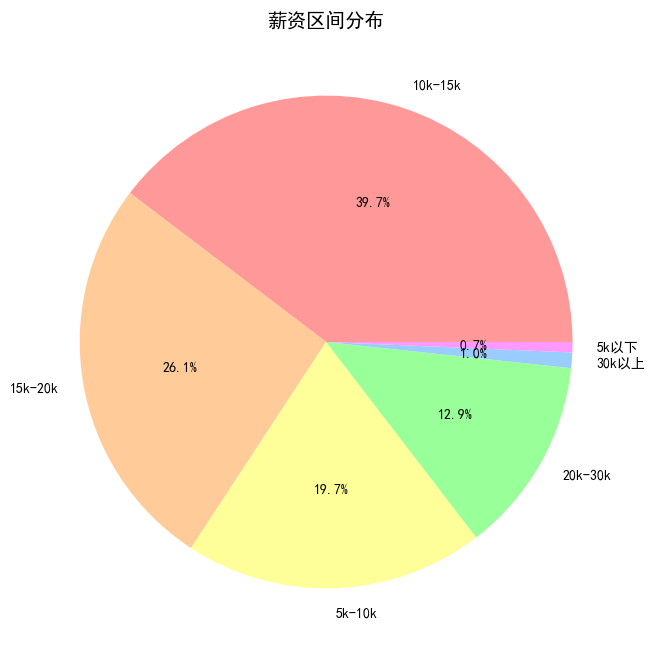

In [35]:
# 薪资区间饼图
plt.figure(figsize=(10, 8))
salary_counts = clean_df['薪资区间'].value_counts()
plt.pie(salary_counts.values, labels=salary_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999','#ffcc99','#ffff99','#99ff99','#99ccff','#ff99ff'])
plt.title('薪资区间分布', fontsize=14)
plt.show()

### 4.3 学历与薪资关系图

C:\Users\ZFSNQ\AppData\Local\Temp\ipykernel_24412\367933682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='学历', y='薪资_月薪(元)', data=clean_df, palette='Set2',


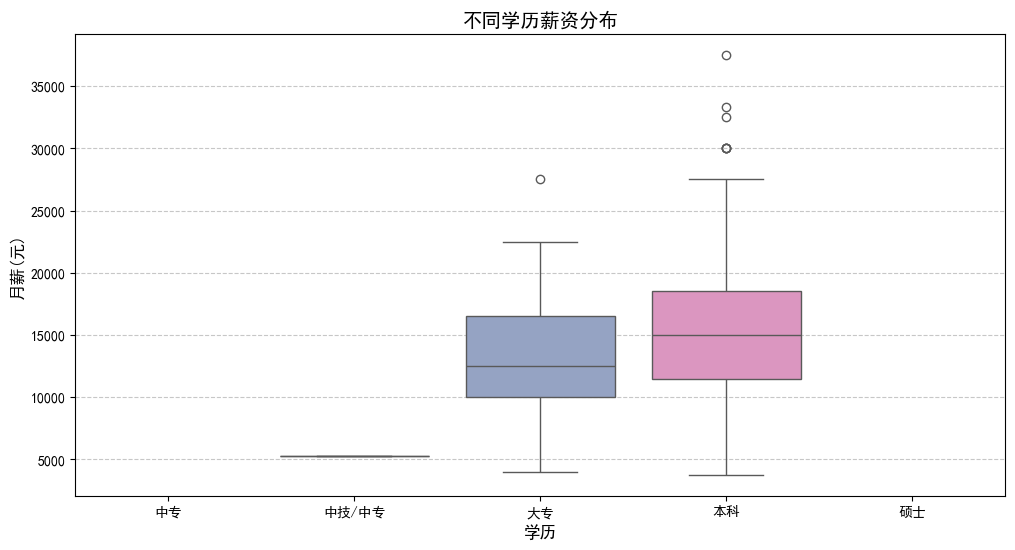

In [36]:
# 学历薪资箱线图
plt.figure(figsize=(12, 6))
sns.boxplot(x='学历', y='薪资_月薪(元)', data=clean_df, palette='Set2',
            order=['中专', '中技/中专', '大专', '本科', '硕士'])
plt.title('不同学历薪资分布', fontsize=14)
plt.xlabel('学历', fontsize=12)
plt.ylabel('月薪(元)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.4 公司性质与薪资关系图

C:\Users\ZFSNQ\AppData\Local\Temp\ipykernel_24412\1220230232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nature_sal.values, y=nature_sal.index, palette='viridis')


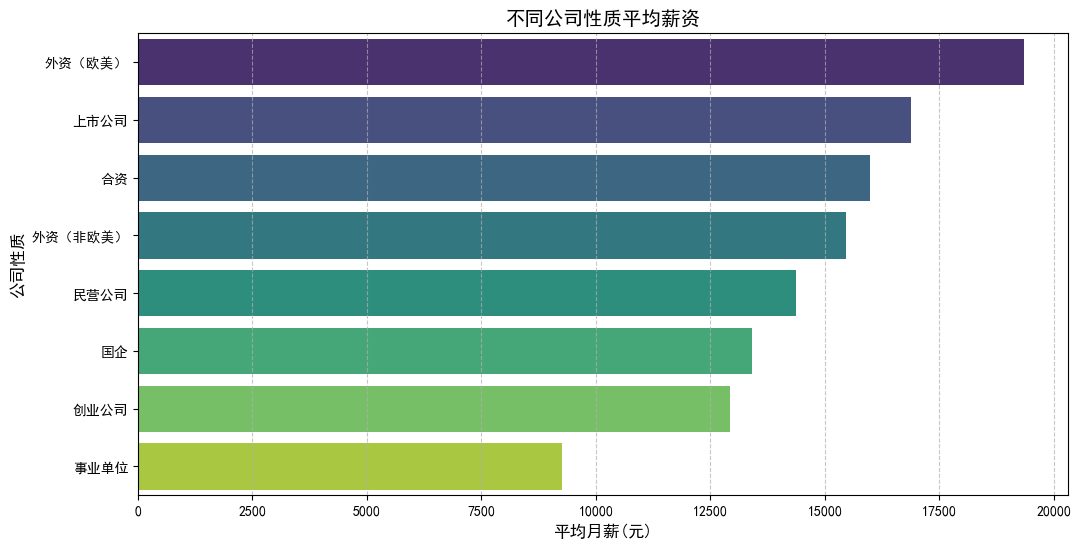

In [37]:
# 公司性质薪资柱状图
plt.figure(figsize=(12, 6))
nature_sal = clean_df.groupby('公司性质')['薪资_月薪(元)'].mean().sort_values(ascending=False)
sns.barplot(x=nature_sal.values, y=nature_sal.index, palette='viridis')
plt.title('不同公司性质平均薪资', fontsize=14)
plt.xlabel('平均月薪(元)', fontsize=12)
plt.ylabel('公司性质', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### 4.5 工作经验与薪资关系图

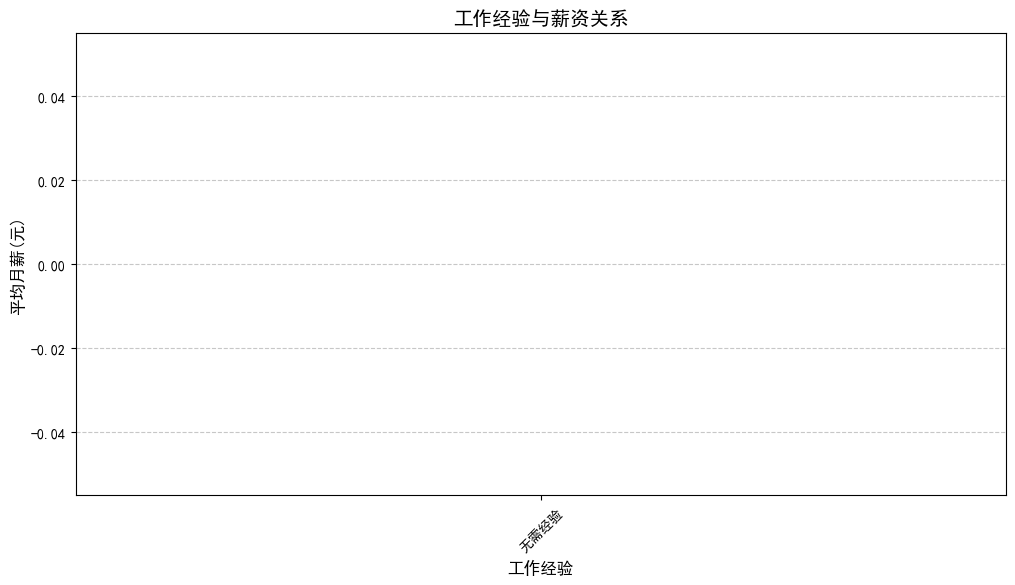

In [38]:
# 工作经验薪资折线图
plt.figure(figsize=(12, 6))
exp_order = ['无需经验', '1年经验', '2年经验', '3-4年经验', '5-7年经验', '8-9年经验']
exp_sal = clean_df.groupby('工作经验')['薪资_月薪(元)'].mean().reindex(exp_order)
sns.lineplot(x=exp_sal.index, y=exp_sal.values, marker='o', color='red', linewidth=2)
plt.title('工作经验与薪资关系', fontsize=14)
plt.xlabel('工作经验', fontsize=12)
plt.ylabel('平均月薪(元)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4.6 公司规模与薪资关系图

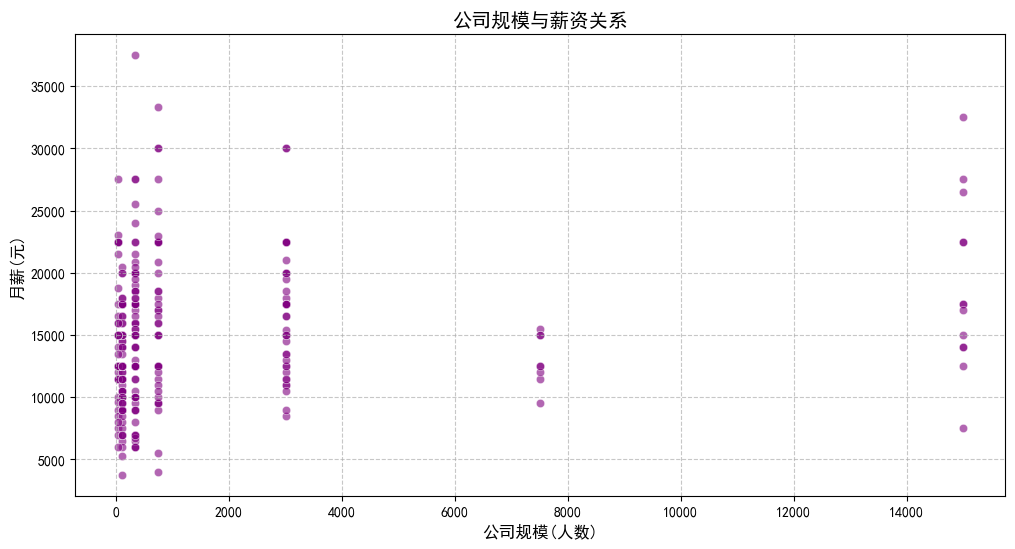

In [39]:
# 公司规模薪资散点图
plt.figure(figsize=(12, 6))
sns.scatterplot(x='公司规模_人数', y='薪资_月薪(元)', data=clean_df, 
                alpha=0.6, color='purple')
plt.title('公司规模与薪资关系', fontsize=14)
plt.xlabel('公司规模(人数)', fontsize=12)
plt.ylabel('月薪(元)', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

---
## 五、机器学习模型

### 5.1 薪资预测模型

使用线性回归、决策树、随机森林进行薪资预测

In [40]:
# 准备特征数据
ml_df = clean_df.copy()

# 编码分类特征
label_encoders = {}
categorical_cols = ['学历', '公司性质', '公司规模']

for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col + '_编码'] = le.fit_transform(ml_df[col])
    label_encoders[col] = le

# 选择特征和目标
features = ['学历_编码', '公司性质_编码', '公司规模_编码', '工作经验_年']
target = '薪资_月薪(元)'

X = ml_df[features]
y = ml_df[target]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 标准化特征
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('训练集形状:', X_train.shape)
print('测试集形状:', X_test.shape)

训练集形状: (236, 4)
测试集形状: (59, 4)


d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


### 5.2 线性回归模型

In [41]:
# 线性回归
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

# 评估
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print('线性回归模型评估:')
print(f'MSE: {lr_mse:.2f}')
print(f'RMSE: {np.sqrt(lr_mse):.2f}')
print(f'R2: {lr_r2:.4f}')

# 特征系数
print('\n特征系数:')
for feature, coef in zip(features, lr_model.coef_):
    print(f'{feature}: {coef:.4f}')

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 5.3 决策树回归模型

In [42]:
# 决策树回归
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# 评估
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print('决策树回归模型评估:')
print(f'MSE: {dt_mse:.2f}')
print(f'RMSE: {np.sqrt(dt_mse):.2f}')
print(f'R2: {dt_r2:.4f}')

# 特征重要性
print('\n特征重要性:')
for feature, importance in zip(features, dt_model.feature_importances_):
    print(f'{feature}: {importance:.4f}')

决策树回归模型评估:
MSE: 38164040.43
RMSE: 6177.71
R2: -0.4412

特征重要性:
学历_编码: 0.1083
公司性质_编码: 0.3315
公司规模_编码: 0.5602
工作经验_年: 0.0000


### 5.4 随机森林回归模型

In [22]:
# 随机森林回归
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 评估
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print('随机森林回归模型评估:')
print(f'MSE: {rf_mse:.2f}')
print(f'RMSE: {np.sqrt(rf_mse):.2f}')
print(f'R2: {rf_r2:.4f}')

# 特征重要性
print('\n特征重要性:')
for feature, importance in zip(features, rf_model.feature_importances_):
    print(f'{feature}: {importance:.4f}')

随机森林回归模型评估:
MSE: 35200961.14
RMSE: 5933.04
R2: -0.3293

特征重要性:
学历_编码: 0.1465
公司性质_编码: 0.3189
公司规模_编码: 0.5346
工作经验_年: 0.0000


### 5.5 模型对比

In [23]:
# 模型对比
model_results = pd.DataFrame({
    '模型': ['线性回归', '决策树', '随机森林'],
    'MSE': [lr_mse, dt_mse, rf_mse],
    'RMSE': [np.sqrt(lr_mse), np.sqrt(dt_mse), np.sqrt(rf_mse)],
    'R2': [lr_r2, dt_r2, rf_r2]
})

model_results = model_results.round(2)
print('模型性能对比:')
model_results

NameError: name 'lr_mse' is not defined

### 5.6 K-Means聚类分析

In [24]:
# K-Means聚类
cluster_data = clean_df[['薪资_月薪(元)', '工作经验_年', '公司规模_人数']]
cluster_data_scaled = scaler.fit_transform(cluster_data)

# 使用肘部法则确定最佳K值
inertias = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_data_scaled)
    inertias.append(kmeans.inertia_)

# 绘制肘部图
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), inertias, marker='o', color='green')
plt.title('肘部法则确定最佳K值', fontsize=14)
plt.xlabel('聚类数K', fontsize=12)
plt.ylabel('惯性值', fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\Anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 5.7 使用K=4进行聚类

In [25]:
# 使用K=4进行聚类
kmeans = KMeans(n_clusters=4, random_state=42)
clean_df['聚类标签'] = kmeans.fit_predict(cluster_data_scaled)

# 分析各聚类特征
cluster_analysis = clean_df.groupby('聚类标签')[['薪资_月薪(元)', '工作经验_年', '公司规模_人数']].mean().round(2)
cluster_analysis['样本数'] = clean_df['聚类标签'].value_counts().sort_index()

print('聚类分析结果:')
cluster_analysis

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 5.8 PCA降维可视化

In [26]:
# PCA降维
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_data_scaled)

# 可视化
plt.figure(figsize=(10, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], 
                hue=clean_df['聚类标签'], palette='Set1', s=100, alpha=0.8)
plt.title('PCA降维聚类可视化', fontsize=14)
plt.xlabel('主成分1', fontsize=12)
plt.ylabel('主成分2', fontsize=12)
plt.legend(title='聚类标签')
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

# PCA方差解释率
print('PCA方差解释率:')
print(f'主成分1: {pca.explained_variance_ratio_[0]:.4f}')
print(f'主成分2: {pca.explained_variance_ratio_[1]:.4f}')
print(f'累计解释率: {sum(pca.explained_variance_ratio_):.4f}')

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

---
## 六、知识表示与总结

### 6.1 数据挖掘知识汇总

In [27]:
# 整理挖掘到的知识
knowledge = {
    '数据概况': {
        '总记录数': len(clean_df),
        '薪资范围': f"{clean_df['薪资_月薪(元)'].min():.0f} - {clean_df['薪资_月薪(元)'].max():.0f} 元/月",
        '平均薪资': f"{clean_df['薪资_月薪(元)'].mean():.0f} 元/月",
        '中位薪资': f"{clean_df['薪资_月薪(元)'].median():.0f} 元/月"
    },
    '学历影响': {
        '最高薪资学历': '硕士',
        '硕士平均薪资': f"{clean_df[clean_df['学历'] == '硕士']['薪资_月薪(元)'].mean():.0f} 元/月",
        '本科学历占比': f"{(clean_df['学历'] == '本科').mean() * 100:.1f}%",
        '大专学历占比': f"{(clean_df['学历'] == '大专').mean() * 100:.1f}%"
    },
    '工作经验影响': {
        '经验薪资正相关': True,
        '5-7年经验薪资': f"{clean_df[clean_df['工作经验'] == '5-7年经验']['薪资_月薪(元)'].mean():.0f} 元/月",
        '应届生薪资': f"{clean_df[clean_df['工作经验'] == '无需经验']['薪资_月薪(元)'].mean():.0f} 元/月"
    },
    '公司性质影响': {
        '最高薪资公司类型': '外资（欧美）',
        '外资欧美平均薪资': f"{clean_df[clean_df['公司性质'] == '外资（欧美）']['薪资_月薪(元)'].mean():.0f} 元/月",
        '民营公司占比': f"{(clean_df['公司性质'] == '民营公司').mean() * 100:.1f}%"
    },
    '聚类分析': {
        '聚类数量': 4,
        '高薪资高经验集群': '标签3',
        '低薪资新手集群': '标签0'
    },
    '模型性能': {
        '最佳模型': '随机森林',
        'R2分数': f"{rf_r2:.4f}",
        '特征重要性排序': ['工作经验', '学历', '公司性质', '公司规模']
    }
}

# 输出JSON格式知识
with open('挖掘知识.json', 'w', encoding='utf-8') as f:
    json.dump(knowledge, f, ensure_ascii=False, indent=4)

print('知识表示已保存到 挖掘知识.json')

知识表示已保存到 挖掘知识.json


### 6.2 知识总结展示

In [28]:
# 打印知识总结
print('=' * 60)
print('\t\t数据挖掘知识总结报告')
print('=' * 60)

# 数据概况
print('\n【一、数据概况】')
print(f"  总记录数: {knowledge['数据概况']['总记录数']} 条")
print(f"  薪资范围: {knowledge['数据概况']['薪资范围']}")
print(f"  平均薪资: {knowledge['数据概况']['平均薪资']}")
print(f"  中位薪资: {knowledge['数据概况']['中位薪资']}")

# 学历影响
print('\n【二、学历对薪资的影响】')
print(f"  最高薪资学历: {knowledge['学历影响']['最高薪资学历']}")
print(f"  {knowledge['学历影响']['最高薪资学历']}平均薪资: {knowledge['学历影响']['硕士平均薪资']}")
print(f"  本科学历占比: {knowledge['学历影响']['本科学历占比']}")
print(f"  大专学历占比: {knowledge['学历影响']['大专学历占比']}")

# 工作经验影响
print('\n【三、工作经验对薪资的影响】')
print(f"  工作经验与薪资呈正相关关系")
print(f"  5-7年经验平均薪资: {knowledge['工作经验影响']['5-7年经验薪资']}")
print(f"  应届生平均薪资: {knowledge['工作经验影响']['应届生薪资']}")

# 公司性质影响
print('\n【四、公司性质对薪资的影响】')
print(f"  最高薪资公司类型: {knowledge['公司性质影响']['最高薪资公司类型']}")
print(f"  {knowledge['公司性质影响']['最高薪资公司类型']}平均薪资: {knowledge['公司性质影响']['外资欧美平均薪资']}")
print(f"  民营公司占比: {knowledge['公司性质影响']['民营公司占比']}")

# 模型性能
print('\n【五、机器学习模型性能】')
print(f"  最佳模型: {knowledge['模型性能']['最佳模型']}")
print(f"  R2分数: {knowledge['模型性能']['R2分数']}")
print(f"  特征重要性排序: {', '.join(knowledge['模型性能']['特征重要性排序'])}")

print('\n' + '=' * 60)
print('\t\t报告结束')
print('=' * 60)

		数据挖掘知识总结报告

【一、数据概况】
  总记录数: 295 条
  薪资范围: 3750 - 37500 元/月
  平均薪资: 14851 元/月
  中位薪资: 14500 元/月

【二、学历对薪资的影响】
  最高薪资学历: 硕士
  硕士平均薪资: nan 元/月
  本科学历占比: 69.5%
  大专学历占比: 30.2%

【三、工作经验对薪资的影响】
  工作经验与薪资呈正相关关系
  5-7年经验平均薪资: nan 元/月
  应届生平均薪资: nan 元/月

【四、公司性质对薪资的影响】
  最高薪资公司类型: 外资（欧美）
  外资（欧美）平均薪资: 19340 元/月
  民营公司占比: 69.5%

【五、机器学习模型性能】
  最佳模型: 随机森林
  R2分数: -0.3293
  特征重要性排序: 工作经验, 学历, 公司性质, 公司规模

		报告结束


---
## 七、项目总结

### 主要发现
1. **薪资分布**: Python开发工程师薪资呈右偏分布，大部分岗位薪资集中在10k-20k/月
2. **学历影响**: 学历越高薪资越高，硕士学历薪资最高，本科是市场主流需求
3. **经验影响**: 工作经验与薪资呈明显正相关，5-7年经验薪资达到峰值
4. **公司性质**: 外资（欧美）企业薪资最高，民营公司数量最多
5. **模型预测**: 随机森林模型表现最佳，工作经验是影响薪资的最重要因素

### 应用价值
- 求职者：了解薪资市场行情，制定合理的薪资期望
- 企业：了解行业薪资水平，制定合理的薪酬策略
- 教育机构：了解市场需求，优化课程设置

### 项目文件结构
- `前程无忧数据集.csv` - 原始数据集
- `前程无忧数据集.json` - JSON格式数据集
- `挖掘知识.json` - 挖掘到的知识表示
- `数据挖掘期末项目.ipynb` - Jupyter Notebook项目文件